# Stored restriction maps visualisations

## 1. Imports

In [120]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

#Cornell improved
# 1 Layer Sheaf
#maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_111032.pt")

# 2-layer Sheaf
# maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_180409.pt")

# 5-layer Sheaf
#maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_181232.pt")

#print(type(maps))

In [121]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
#B=B.astype(int)
    F=L-B
    return B , F

## 2. Load

In [122]:
hidden_channels = 32
dataset = "chameleon"
layers = 3
epochs = 300

MAPS = []
for layer in range(layers):
    MAPS.append(torch.load(f"../results/maps/{dataset}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold0_seed43.pt"))

In [ ]:
DF = []

for maps in MAPS:
    df = pd.DataFrame(maps.cpu().tolist(), columns=["source", "target", "map_value"])
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    DF.append(df)
df

,source,target,map_value
31371,0,2322,0.999999
31372,0,3334,0.997844
31373,0,3982,0.998822
31374,0,4260,0.999999
31375,0,4312,0.999711
...,...,...,...
62740,4526,4540,-0.684887
31368,4527,4533,0.995625
31369,4527,4541,0.979381
62741,4536,4544,-1.000000


: 

In [ ]:
B_list = []
L0_LIST = []
L1_LIST = []
f0_list = []
f1_list = []

for df in DF:

    df = df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)

    # signed value
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    # canonical undirected edge label
    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),axis=1)

    # build node-by-edge matrix
    nodes = sorted(set(df["source"]).union(df["target"]))
    edges = sorted(df["edge"].unique())

    B = df.pivot(index="source", columns="edge", values="signed_map")
    B = B.reindex(index=nodes, columns=edges, fill_value=0)

    B.fillna(0, inplace=True)
    B_np = B.to_numpy(dtype=float)
    L0 = B_np @ B_np.T
    L1 = B_np.T @ B_np
    B1, F1 = fbc(L1)
    B0, F0 = fbc(L0)
    L0_LIST.append(L0)
    L1_LIST.append(L1)
    f0_list.append(np.diag(F0))
    f1_list.append(np.diag(F1))
    B_list.append(B)
    

In [ ]:
EDGE_LIST = [list(B.columns) for B in B_list]
NODE_LIST = [B.index.tolist() for B in B_list]

print(EDGE_LIST[0] == EDGE_LIST[1] == EDGE_LIST[2] == EDGE_LIST[3] == EDGE_LIST[4])
print(NODE_LIST[0] == NODE_LIST[1] == NODE_LIST[2] == NODE_LIST[3] == NODE_LIST[4])

True
True


In [ ]:
edge_list = list(B.columns)
print(edge_list)

[(np.float64(0.0), np.float64(42.0)), (np.float64(1.0), np.float64(82.0)), (np.float64(1.0), np.float64(90.0)), (np.float64(1.0), np.float64(99.0)), (np.float64(1.0), np.float64(148.0)), (np.float64(2.0), np.float64(42.0)), (np.float64(3.0), np.float64(42.0)), (np.float64(3.0), np.float64(163.0)), (np.float64(4.0), np.float64(8.0)), (np.float64(4.0), np.float64(25.0)), (np.float64(4.0), np.float64(40.0)), (np.float64(4.0), np.float64(55.0)), (np.float64(4.0), np.float64(72.0)), (np.float64(4.0), np.float64(152.0)), (np.float64(4.0), np.float64(156.0)), (np.float64(5.0), np.float64(37.0)), (np.float64(5.0), np.float64(42.0)), (np.float64(6.0), np.float64(11.0)), (np.float64(6.0), np.float64(42.0)), (np.float64(6.0), np.float64(132.0)), (np.float64(6.0), np.float64(143.0)), (np.float64(6.0), np.float64(145.0)), (np.float64(7.0), np.float64(110.0)), (np.float64(7.0), np.float64(121.0)), (np.float64(8.0), np.float64(42.0)), (np.float64(8.0), np.float64(65.0)), (np.float64(9.0), np.float64(

In [ ]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)

B_top = nx.incidence_matrix(G).todense()
L0_top = B_top @ B_top.T
L1_top = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top = np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

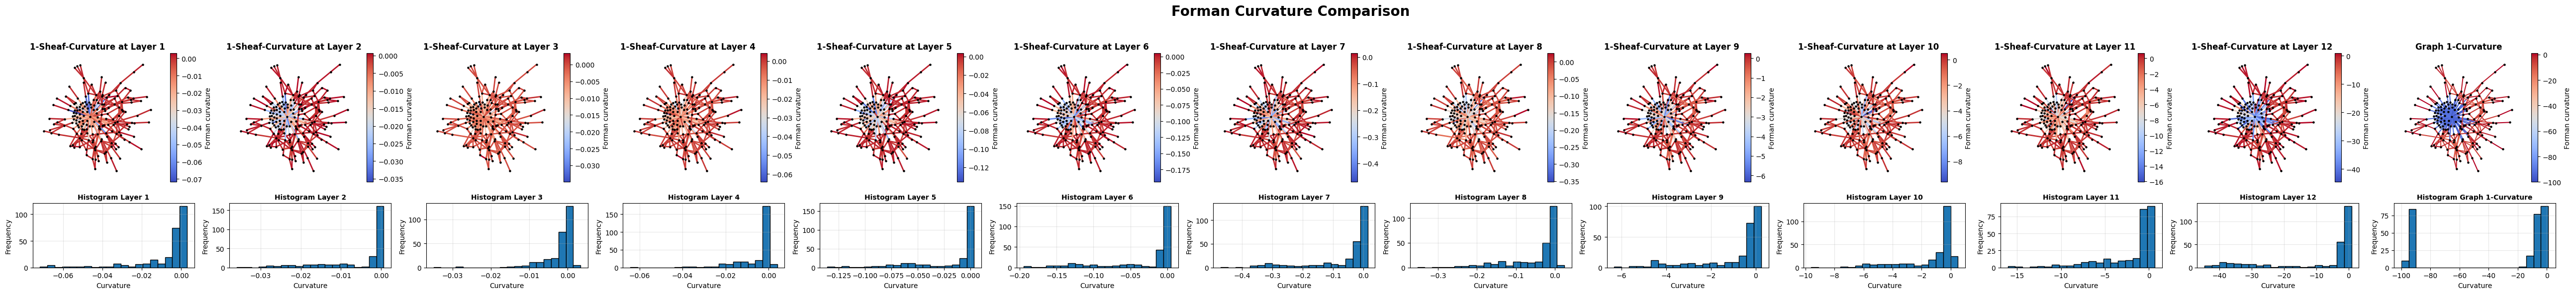

In [ ]:
pos = nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(4 * (layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

for layer in range(layers):
    curvatures = np.asarray(f1_list[layer])

    # ----- Top row: graph -----
    ax_graph = ax[0, layer]
    nx.draw_networkx_nodes(
        G, ax=ax_graph, pos=pos,
        node_color='k', node_size=5
    )

    norm = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())
    nx.draw_networkx_edges(
        G, ax=ax_graph, pos=pos,
        edge_color=cmap(norm(curvatures)),
        width=2
    )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax_graph, label='Forman curvature')

    ax_graph.set_title(
        f"1-Sheaf-Curvature at Layer {layer+1}",
        fontweight="bold", fontsize=12
    )
    ax_graph.axis("off")

    # ----- Bottom row: histogram -----
    ax_hist = ax[1, layer]
    ax_hist.hist(curvatures, bins=20, edgecolor="black")
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10, fontweight="bold"
    )
    ax_hist.set_xlabel("Curvature")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)


# ----- Last column: top graph curvature -----
curvatures_top = np.asarray(f1_top)

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G, ax=ax_graph, pos=pos,
    node_color='k', node_size=5
)

norm_top = plt.Normalize(vmin=curvatures_top.min(), vmax=curvatures_top.max())
nx.draw_networkx_edges(
    G, ax=ax_graph, pos=pos,
    edge_color=cmap(norm_top(curvatures_top)),
    width=1.5
)

sm_top = plt.cm.ScalarMappable(cmap=cmap, norm=norm_top)
sm_top.set_array([])
plt.colorbar(sm_top, ax=ax_graph, label='Forman curvature')

ax_graph.set_title(
    "Graph 1-Curvature",
    fontweight="bold", fontsize=12
)
ax_graph.axis("off")

# ----- Bottom row: histogram for top curvature -----
ax_hist = ax[1, layers]
ax_hist.hist(curvatures_top, bins=20, edgecolor="black")
ax_hist.set_title(
    "Histogram Graph 1-Curvature",
    fontsize=10, fontweight="bold"
)
ax_hist.set_xlabel("Curvature")
ax_hist.set_ylabel("Frequency")
ax_hist.grid(alpha=0.3)

fig.suptitle("Forman Curvature Comparison", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

os.makedirs("../results/images", exist_ok=True)
fig.savefig(f"../results/images/1-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)

In [ ]:
with open(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", "r") as f:
    # for line in f:
    #     print(line.strip())
    df_node_feature = pd.read_csv(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", sep="\t")

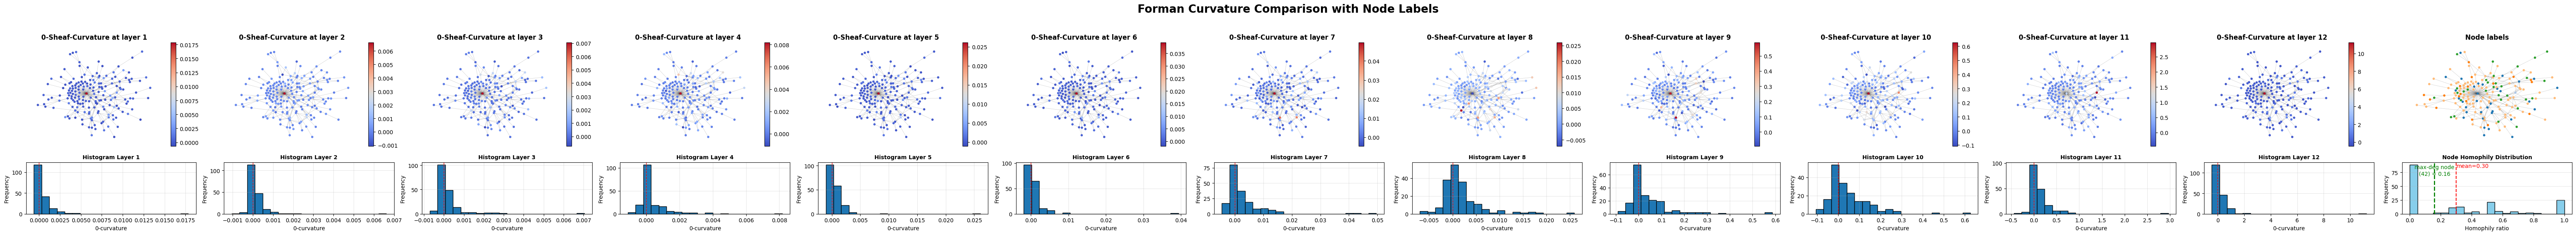

In [ ]:
from tkinter import font


lab = df_node_feature["label"].values
# display(lab)

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(5 * (layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

# ---------- Sheaf curvature layers ----------
for layer in range(layers):
    curvatures = np.asarray(f0_list[layer])

    # Top row: graph
    ax_graph = ax[0, layer]
    norm0 = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())

    nx.draw_networkx_nodes(
        G,
        ax=ax_graph,
        node_color=cmap(norm0(curvatures)),
        pos=pos_use,
        node_size=10
    )
    nx.draw_networkx_edges(
        G,
        ax=ax_graph,
        pos=pos_use,
        width=0.5,
        alpha=0.2
    )

    sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
    sm0.set_array([])
    plt.colorbar(sm0, ax=ax_graph)

    ax_graph.set_title(
        f"0-Sheaf-Curvature at layer {layer+1}",
        fontweight="bold",
        fontsize=12
    )
    ax_graph.axis("off")

    # Bottom row: histogram
    ax_hist = ax[1, layer]
    ax_hist.hist(curvatures, bins=20, edgecolor="black")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10,
        fontweight="bold"
    )
    ax_hist.set_xlabel("0-curvature")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)


# ---------- Last column: node labels ----------
labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n])] % 20) for n in sorted(G.nodes())]

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G,
    ax=ax_graph,
    node_color=node_colors,
    node_size=10,
    pos=pos_use
)
nx.draw_networkx_edges(
    G,
    ax=ax_graph,
    pos=pos_use,
    alpha=0.2,
    width=0.5
)
ax_graph.set_title("Node labels", fontweight="bold", fontsize=12)
ax_graph.axis("off")

# ----- Bottom-right: homophily ratio histogram -----
homophily_ratios = {}

for node in G.nodes():
    neigh_edges = [_ for _ in list(G.edges()) if node in _]
    neigh_nodes = [int(j) if i == node else int(i) for (i, j) in neigh_edges]

    if len(neigh_nodes) == 0:
        homophily_ratios[node] = 0.0
        continue

    ratio = sum(1 for n in neigh_nodes if lab[n] == lab[node]) / len(neigh_nodes)
    homophily_ratios[node] = ratio

ax_hom = ax[1, layers]

ax_hom.hist(
    list(homophily_ratios.values()),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

ax_hom.set_title(
    "Node Homophily Distribution",
    fontsize=10,
    fontweight="bold"
)
ax_hom.set_xlabel("Homophily ratio")
ax_hom.set_ylabel("Frequency")
ax_hom.grid(axis='y', alpha=0.3)

# Optional: mean line (very useful)
mean_h = np.mean(list(homophily_ratios.values()))
ax_hom.axvline(mean_h, color="red", linestyle="--", linewidth=1.5)
ax_hom.text(mean_h, ax_hom.get_ylim()[1]*0.9, f"mean={mean_h:.2f}", color="red", fontsize=10)

degrees = dict(G.degree())
max_deg_node = max(degrees, key=degrees.get)
max_deg_hom = homophily_ratios[max_deg_node]

ax_hom.axvline(max_deg_hom, color="green", linestyle="--", linewidth=2)

ax_hom.text(
    max_deg_hom,
    ax_hom.get_ylim()[1]*0.75,
    f"max-deg node\n({max_deg_node}) = {max_deg_hom:.2f}",
    color="green",
    ha="center"
)

fig.suptitle("Forman Curvature Comparison with Node Labels", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

os.makedirs("../results/images", exist_ok=True)
fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)